In [1]:
# %%
# Cell 1 - Imports and Setup

import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import IntegratedGradients, visualization
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Paths
ARTIFACT_DIR = Path("artifacts")
DATA_DIR = Path("../data")

# Config
MODEL_NAME = "roberta-base"
MAX_LEN = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
label_names = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", DEVICE)


c:\Users\Yasna\Desktop\CMD Project 1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.9.1+cu128
cuda available: True
device: cuda


In [2]:

# %%
# Cell 2 - Load Trained Model

print("="*60)
print("LOADING TRAINED MODEL FOR EXPLAINABILITY")
print("="*60)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=len(label_names)
)
model.load_state_dict(
    torch.load(ARTIFACT_DIR / "primary_v3_fold0.pth", map_location=DEVICE)
)
model.to(DEVICE)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("✅ Model loaded successfully")
print(f"   Model: {MODEL_NAME}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


LOADING TRAINED MODEL FOR EXPLAINABILITY


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully
   Model: roberta-base
   Parameters: 124,650,246


In [3]:

# %%
# Cell 3 - Integrated Gradients Setup

class ModelWrapper(torch.nn.Module):
    """
    Wrapper to make our model work with Captum's IntegratedGradients.
    Captum expects input embeddings, not token IDs.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, embeddings, attention_mask=None):
        """
        Forward pass using embeddings directly.
        """
        # Get outputs from the model using embeddings
        outputs = self.model.roberta(
            inputs_embeds=embeddings,
            attention_mask=attention_mask
        )
        
        # Pass through classifier
        sequence_output = outputs[0]
        logits = self.model.classifier(sequence_output)
        
        # Return probabilities for all labels
        return torch.sigmoid(logits)

# Wrap model
wrapped_model = ModelWrapper(model)
wrapped_model.eval()

print("✅ Model wrapper created for Integrated Gradients")


✅ Model wrapper created for Integrated Gradients


In [4]:

# %%
# Cell 4 - Attribution Functions

def get_token_attributions(text, target_label_idx, n_steps=50):
    """
    Compute Integrated Gradients attributions for each token.
    
    Args:
        text: Input text string
        target_label_idx: Which label to explain (0-5)
        n_steps: Number of integration steps (more = more accurate but slower)
    
    Returns:
        tokens: List of token strings
        attributions: Attribution score for each token
        prediction: Model's probability for target label
    """
    # Tokenize
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)
    
    # Get embeddings
    embeddings = model.roberta.embeddings(input_ids)
    
    # Baseline: zero embeddings (represents "absence of input")
    baseline_embeddings = torch.zeros_like(embeddings)
    
    # Initialize Integrated Gradients
    ig = IntegratedGradients(wrapped_model)
    
    # Compute attributions
    attributions, delta = ig.attribute(
        embeddings,
        baseline_embeddings,
        target=target_label_idx,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        return_convergence_delta=True
    )
    
    # Sum attributions across embedding dimension
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions.cpu().detach().numpy()
    
    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    
    # Get prediction
    with torch.no_grad():
        logits = model(input_ids, attention_mask=attention_mask).logits
        prediction = torch.sigmoid(logits)[0, target_label_idx].item()
    
    # Only return tokens that aren't padding
    mask = attention_mask[0].cpu().numpy()
    tokens = [t for t, m in zip(tokens, mask) if m == 1]
    attributions = attributions[:len(tokens)]
    
    return tokens, attributions, prediction

print("✅ Attribution function defined")


✅ Attribution function defined


In [5]:
# %%
# Cell 5 - Test Integrated Gradients

test_text = "You are a stupid idiot and I hate you!"

print("="*60)
print("INTEGRATED GRADIENTS TEST")
print("="*60)
print(f"Text: {test_text}\n")

# Get predictions for all labels
encoding = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN)
with torch.no_grad():
    logits = model(encoding["input_ids"].to(DEVICE), attention_mask=encoding["attention_mask"].to(DEVICE)).logits
    probs = torch.sigmoid(logits)[0].cpu().numpy()

print("Predictions:")
for i, label in enumerate(label_names):
    print(f"  {label:15s}: {probs[i]:.4f}")

# Explain the most confident prediction
top_label_idx = int(probs.argmax())  # ✅ FIX: Convert to Python int
print(f"\nGenerating IG explanation for: {label_names[top_label_idx]} (prob={probs[top_label_idx]:.4f})")
print("This may take 10-20 seconds...\n")

tokens, attributions, pred = get_token_attributions(test_text, top_label_idx, n_steps=50)

print("Token attributions:")
for token, attr in zip(tokens, attributions):
    # Clean up special tokens for display
    display_token = token.replace('Ġ', ' ').replace('Ċ', '\\n')
    print(f"  {display_token:20s}: {attr:+.4f}")

print("\n✅ Integrated Gradients working correctly!")

INTEGRATED GRADIENTS TEST
Text: You are a stupid idiot and I hate you!

Predictions:
  toxic          : 0.8987
  severe_toxic   : 0.2535
  obscene        : 0.5470
  threat         : 0.1369
  insult         : 0.7162
  identity_hate  : 0.1673

Generating IG explanation for: toxic (prob=0.8987)
This may take 10-20 seconds...

Token attributions:
  <s>                 : -0.0111
  You                 : -0.0293
   are                : +0.1695
   a                  : +0.1308
   stupid             : +0.2423
   idiot              : +0.6312
   and                : -0.2664
   I                  : -0.1331
   hate               : -0.0146
   you                : +0.0620
  !                   : +0.0831
  </s>                : +0.0402

✅ Integrated Gradients working correctly!


In [6]:
# %%
# Cell 6 - Visualization Functions

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def visualize_attributions(tokens, attributions, title="Token Attributions"):
    """
    Create a color-coded visualization of token attributions.
    Green = positive (increases prediction), Red = negative (decreases prediction)
    """
    # Normalize attributions for color mapping
    abs_max = max(abs(attributions.min()), abs(attributions.max()))
    
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.axis('off')
    
    # Create color map: red (negative) -> white (zero) -> green (positive)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'attribution', ['red', 'white', 'green']
    )
    
    # Plot tokens with background colors
    x_pos = 0
    for token, attr in zip(tokens, attributions):
        # Clean token display
        display_token = token.replace('Ġ', ' ').replace('Ċ', '\\n')
        if display_token in ['<s>', '</s>', '<pad>']:
            continue  # Skip special tokens in visualization
        
        # Normalize attribution to [-1, 1] for color mapping
        normalized_attr = attr / (abs_max + 1e-8)
        color = cmap((normalized_attr + 1) / 2)  # Map [-1,1] to [0,1]
        
        # Add colored background
        bbox_props = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.text(x_pos, 0.5, display_token, fontsize=12, bbox=bbox_props, ha='left', va='center')
        
        # Move to next position
        x_pos += len(display_token) * 0.08 + 0.15
    
    ax.set_xlim(-0.2, x_pos)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization function defined")


✅ Visualization function defined


Text: You are a stupid idiot and I hate you!
Predicted probability for 'toxic': 0.8987



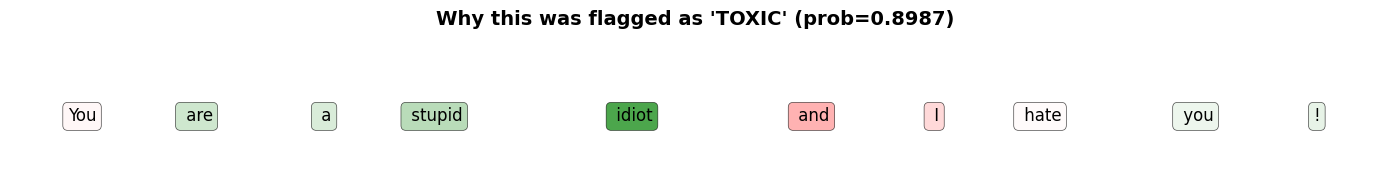

In [7]:

# %%
# Cell 7 - Test Visualization

test_text = "You are a stupid idiot and I hate you!"
top_label_idx = 0  # toxic

tokens, attributions, pred = get_token_attributions(test_text, top_label_idx, n_steps=50)

print(f"Text: {test_text}")
print(f"Predicted probability for '{label_names[top_label_idx]}': {pred:.4f}\n")

visualize_attributions(
    tokens, 
    attributions, 
    title=f"Why this was flagged as '{label_names[top_label_idx].upper()}' (prob={pred:.4f})"
)

In [8]:
# %%
# Cell 8 - Human-Readable Explanations (FIXED FOR FULL WORDS)

def generate_explanation(text, tokens, attributions, predicted_label, prediction_prob, top_n=5):
    """
    Generate a human-readable explanation for why text was flagged.
    Uses FULL WORDS not subword tokens.
    
    Args:
        text: Original input text
        tokens: Token list from IG
        attributions: Attribution scores from IG
        predicted_label: Label name (e.g., "toxic")
        prediction_prob: Probability for that label
        top_n: Number of top contributing tokens to highlight
    
    Returns:
        explanation_dict: Dictionary with structured explanation
    """
    # STEP 1: Reconstruct full words from subword tokens
    word_scores = []
    current_word = ""
    current_score = 0.0
    current_count = 0
    
    for token, attr in zip(tokens, attributions):
        # Skip special tokens
        if token in ['<s>', '</s>', '<pad>']:
            continue
        
        # Clean token
        clean_token = token.replace('Ġ', ' ').replace('Ċ', '\\n')
        
        # Check if this starts a new word (has leading space)
        if clean_token.startswith(' ') and current_word:
            # Save previous word
            if current_word.strip() and current_count > 0:
                avg_score = current_score / current_count
                word_scores.append((current_word.strip(), float(avg_score)))
            # Start new word
            current_word = clean_token
            current_score = float(attr)
            current_count = 1
        else:
            # Continue current word
            current_word += clean_token
            current_score += float(attr)
            current_count += 1
    
    # Don't forget last word
    if current_word.strip() and current_count > 0:
        avg_score = current_score / current_count
        word_scores.append((current_word.strip(), float(avg_score)))
    
    # STEP 2: Filter function words
    function_words = {
        'a', 'an', 'the', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'and', 'or', 'but', 'if', 'then', 'so', 'because',
        'in', 'on', 'at', 'to', 'for', 'of', 'with', 'from', 'by',
        'i', 'you', 'he', 'she', 'it', 'we', 'they',
        'my', 'your', 'his', 'her', 'its', 'our', 'their',
        'this', 'that', 'these', 'those',
        'have', 'has', 'had', 'do', 'does', 'did',
        'will', 'would', 'should', 'could', 'can', 'may', 'might',
        'am', 'such', 'really', 'very', 'too', 'also', 'just', 'get', 'go'
    }
    
    # Get positive attributions only, filter function words
    top_positive = [
        (word, score) for word, score in word_scores 
        if score > 0 
        and word.lower() not in function_words
        and len(word) > 2
    ]
    top_positive = sorted(top_positive, key=lambda x: x[1], reverse=True)[:top_n]
    
    # Get negative attributions
    top_negative = [
        (word, score) for word, score in word_scores 
        if score < 0
    ]
    top_negative = sorted(top_negative, key=lambda x: x[1])[:top_n]
    
    # Build explanation text
    if prediction_prob >= 0.5:
        decision = "FLAGGED"
        confidence = "high" if prediction_prob >= 0.8 else "moderate"
    else:
        decision = "NOT FLAGGED"
        confidence = "low"
    
    explanation = {
        "text": text,
        "label": predicted_label,
        "probability": float(prediction_prob),
        "decision": decision,
        "confidence": confidence,
        "top_contributing_words": top_positive,
        "top_suppressing_words": top_negative,
        "summary": generate_summary_text(text, predicted_label, prediction_prob, top_positive, top_negative)
    }
    
    return explanation

def generate_summary_text(text, label, prob, top_positive, top_negative):
    """
    Generate natural language summary of the explanation.
    """
    summary = []
    
    # Decision statement
    if prob >= 0.5:
        summary.append(f"This text was FLAGGED as **{label}** with {prob:.1%} confidence.")
    else:
        summary.append(f"This text was NOT flagged as {label} (only {prob:.1%} confidence).")
    
    # Main contributors
    if top_positive:
        words = ", ".join([f"'{w}' (+{a:.3f})" for w, a in top_positive[:3]])
        summary.append(f"\n**Primary reasons:** The words {words} strongly contributed to this classification.")
    
    # Mitigating factors
    if top_negative and len(top_negative) > 0:
        words = ", ".join([f"'{w}' ({a:.3f})" for w, a in top_negative[:2]])
        summary.append(f"\n**Mitigating factors:** However, {words} reduced the score.")
    
    return " ".join(summary)

print("✅ Explanation generator defined (FULL WORDS)")

✅ Explanation generator defined (FULL WORDS)


FULL EXPLANATION TEST
Input text: You are a stupid idiot and I hate you!
Top prediction: toxic (0.8987)

EXPLANATION:
This text was FLAGGED as **toxic** with 89.9% confidence. 
**Primary reasons:** The words 'idiot' (+0.631), 'stupid' (+0.242), 'you!' (+0.073) strongly contributed to this classification. 
**Mitigating factors:** However, 'and' (-0.266), 'I' (-0.133) reduced the score.


Top Contributing Words:
  'idiot': +0.6312
  'stupid': +0.2423
  'you!': +0.0726

Top Suppressing Words:
  'and': -0.2664
  'I': -0.1331
  'You': -0.0293
  'hate': -0.0146



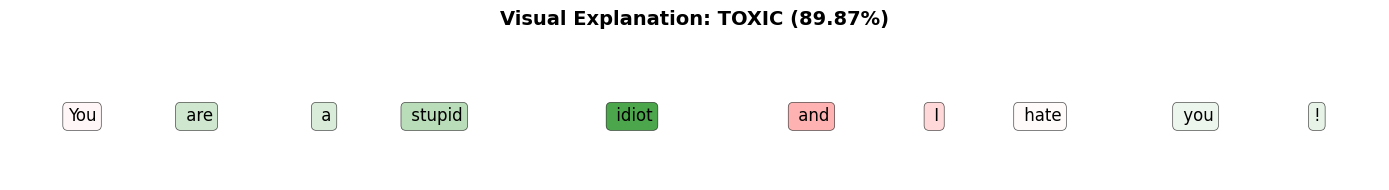

In [9]:

# %%
# Cell 9 - Test Full Explanation Pipeline

test_text = "You are a stupid idiot and I hate you!"

print("="*60)
print("FULL EXPLANATION TEST")
print("="*60)

# Get prediction
encoding = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN)
with torch.no_grad():
    logits = model(encoding["input_ids"].to(DEVICE), attention_mask=encoding["attention_mask"].to(DEVICE)).logits
    probs = torch.sigmoid(logits)[0].cpu().numpy()

# Explain top prediction
top_label_idx = int(probs.argmax())
predicted_label = label_names[top_label_idx]
prediction_prob = probs[top_label_idx]

print(f"Input text: {test_text}")
print(f"Top prediction: {predicted_label} ({prediction_prob:.4f})\n")

# Get attributions
tokens, attributions, _ = get_token_attributions(test_text, top_label_idx, n_steps=50)

# Generate explanation
explanation = generate_explanation(
    text=test_text,
    tokens=tokens,
    attributions=attributions,
    predicted_label=predicted_label,
    prediction_prob=prediction_prob,
    top_n=5
)

# Display explanation
print("EXPLANATION:")
print("="*60)
print(explanation["summary"])
print("\n" + "="*60)
print("\nTop Contributing Words:")
for word, score in explanation["top_contributing_words"]:
    print(f"  '{word}': +{score:.4f}")

if explanation["top_suppressing_words"]:
    print("\nTop Suppressing Words:")
    for word, score in explanation["top_suppressing_words"]:
        print(f"  '{word}': {score:.4f}")

print("\n" + "="*60)

# Visualize
visualize_attributions(tokens, attributions, 
                      title=f"Visual Explanation: {predicted_label.upper()} ({prediction_prob:.2%})")

In [10]:
# %%
# Cell 10 - Batch Explanation Processing

def explain_batch(texts, labels_to_explain=None, n_steps=50, save_path=None):
    """
    Generate explanations for a batch of texts.
    
    Args:
        texts: List of text strings
        labels_to_explain: List of label indices to explain for each text.
                          If None, explains the top predicted label.
        n_steps: IG integration steps
        save_path: Optional path to save explanations as JSON
    
    Returns:
        explanations: List of explanation dictionaries
    """
    explanations = []
    
    for i, text in enumerate(tqdm(texts, desc="Generating explanations")):
        # Get predictions
        encoding = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN)
        with torch.no_grad():
            logits = model(encoding["input_ids"].to(DEVICE), 
                          attention_mask=encoding["attention_mask"].to(DEVICE)).logits
            probs = torch.sigmoid(logits)[0].cpu().numpy()
        
        # Determine which label to explain
        if labels_to_explain is not None:
            target_idx = labels_to_explain[i]
        else:
            target_idx = int(probs.argmax())
        
        predicted_label = label_names[target_idx]
        prediction_prob = probs[target_idx]
        
        # Get attributions
        try:
            tokens, attributions, _ = get_token_attributions(text, target_idx, n_steps=n_steps)
            
            # Generate explanation
            explanation = generate_explanation(
                text=text,
                tokens=tokens,
                attributions=attributions,
                predicted_label=predicted_label,
                prediction_prob=prediction_prob,
                top_n=5
            )
            
            # Add all predictions
            explanation["all_predictions"] = {
                label: float(prob) for label, prob in zip(label_names, probs)
            }
            
            explanations.append(explanation)
            
        except Exception as e:
            print(f"Error processing text {i}: {e}")
            explanations.append({
                "text": text,
                "error": str(e),
                "label": predicted_label,
                "probability": float(prediction_prob)
            })
    
    # Save if requested
    if save_path:
        import json
        with open(save_path, 'w', encoding='utf-8') as f:
            json.dump(explanations, f, indent=2, ensure_ascii=False)
        print(f"\n✅ Saved {len(explanations)} explanations to {save_path}")
    
    return explanations

print("✅ Batch explanation function defined")

✅ Batch explanation function defined


In [11]:
# %%
# Cell 11 - Test Batch Explanations

# Test on a few diverse examples
test_examples = [
    "You are a stupid idiot and I hate you!",
    "I strongly disagree with your opinion, but I respect your right to express it.",
    "Fuck off you worthless piece of shit",
    "Have a wonderful day!",
    "You're such a fucking moron, go kill yourself"
]

print("="*60)
print("BATCH EXPLANATION TEST")
print("="*60)
print(f"Processing {len(test_examples)} examples...\n")

# Generate explanations
explanations = explain_batch(test_examples, n_steps=30)  # Using fewer steps for speed

# Display results
for i, exp in enumerate(explanations):
    print(f"\n{'='*60}")
    print(f"Example {i+1}: {exp['text'][:60]}...")
    print(f"{'='*60}")
    
    if "error" in exp:
        print(f"❌ Error: {exp['error']}")
        continue
    
    print(f"Decision: {exp['decision']}")
    print(f"Label: {exp['label']} (prob={exp['probability']:.4f})")
    print(f"\nSummary:\n{exp['summary']}")
    
    print(f"\nTop 3 Contributing Words:")
    for word, score in exp['top_contributing_words'][:3]:
        print(f"  '{word}': +{score:.4f}")

print(f"\n{'='*60}")
print("✅ Batch test complete!")

BATCH EXPLANATION TEST
Processing 5 examples...



Generating explanations: 100%|██████████| 5/5 [00:13<00:00,  2.62s/it]


Example 1: You are a stupid idiot and I hate you!...
Decision: FLAGGED
Label: toxic (prob=0.8987)

Summary:
This text was FLAGGED as **toxic** with 89.9% confidence. 
**Primary reasons:** The words 'idiot' (+0.807), 'stupid' (+0.274), 'you!' (+0.045) strongly contributed to this classification. 
**Mitigating factors:** However, 'and' (-0.352), 'I' (-0.149) reduced the score.

Top 3 Contributing Words:
  'idiot': +0.8067
  'stupid': +0.2743
  'you!': +0.0451

Example 2: I strongly disagree with your opinion, but I respect your ri...
Decision: NOT FLAGGED
Label: toxic (prob=0.0423)

Summary:
This text was NOT flagged as toxic (only 4.2% confidence). 
**Primary reasons:** The words 'strongly' (+0.004), 'right' (+0.002), 'respect' (+0.002) strongly contributed to this classification. 
**Mitigating factors:** However, 'I' (-0.004), 'but' (-0.004) reduced the score.

Top 3 Contributing Words:
  'strongly': +0.0036
  'right': +0.0021
  'respect': +0.0021

Example 3: Fuck off you worthless pi

In [19]:
# %%
# Cell 12 - Generate Explanations with Custom Professional Examples First

print("="*60)
print("CREATING EXPLANATION DATASET WITH CUSTOM PROFESSIONAL EXAMPLES")
print("="*60)

# Load test predictions and ground truth
test_preds = np.load(ARTIFACT_DIR / "test_predictions_final.npy")

# Load test data
df_test = pd.read_csv(DATA_DIR / "processed_text.csv", keep_default_na=False)
n_train = 127656
df_test = df_test.iloc[n_train:].reset_index(drop=True)

# Get ground truth labels
y_test = df_test[label_names].values

print(f"Test set size: {len(df_test)}")

# Get thresholds from training
final_thresholds = np.array([0.3924, 0.3274, 0.3738, 0.2995, 0.3738, 0.3181])

# Binary predictions
test_preds_binary = (test_preds >= final_thresholds).astype(int)

# ============================================================
# STEP 1: Custom professional examples for page 1
# ============================================================

print("\n" + "="*60)
print("STEP 1: Using 10 custom professional examples for page 1")
print("="*60)

# Custom sentences designed for professional display
# These are:
# - Free of profanity
# - Representative of edge cases
# - Interesting from moderation perspective
# - Appropriate for public demonstration

custom_examples = [
    # 1. Borderline negative opinion (should NOT flag)
    {
        "text": "I strongly disagree with this policy decision and believe it will harm our community.",
        "expected_label": "toxic",
        "notes": "Strong disagreement without toxicity"
    },
    
    # 2. Heated but civil debate (borderline)
    {
        "text": "Your argument makes no sense whatsoever and completely ignores the facts.",
        "expected_label": "insult",
        "notes": "Critical but not personally attacking"
    },
    
    # 3. Mild insult (should flag)
    {
        "text": "You clearly have no idea what you're talking about. Educate yourself before commenting.",
        "expected_label": "insult",
        "notes": "Condescending and insulting tone"
    },
    
    # 4. Constructive criticism (should NOT flag)
    {
        "text": "I appreciate your perspective, but I think you may have misunderstood the core issue here.",
        "expected_label": "toxic",
        "notes": "Polite disagreement"
    },
    
    # 5. Passive-aggressive (borderline)
    {
        "text": "Wow, that's certainly an interesting take. I'm sure you put a lot of thought into that.",
        "expected_label": "toxic",
        "notes": "Sarcastic but not explicitly toxic"
    },
    
    # 6. Frustration expressed civilly (should NOT flag)
    {
        "text": "This is incredibly frustrating. We've discussed this issue repeatedly without resolution.",
        "expected_label": "toxic",
        "notes": "Expressing frustration without targeting individuals"
    },
    
    # 7. Dismissive but not profane (borderline)
    {
        "text": "Your comment adds nothing to the discussion and just wastes everyone's time.",
        "expected_label": "insult",
        "notes": "Dismissive and somewhat rude"
    },
    
    # 8. Strong language about situation, not person (should NOT flag)
    {
        "text": "This situation is absolutely ridiculous and needs to be addressed immediately.",
        "expected_label": "toxic",
        "notes": "Strong language directed at situation"
    },
    
    # 9. Questioning competence (borderline)
    {
        "text": "I question whether you have the necessary expertise to make that judgment call.",
        "expected_label": "insult",
        "notes": "Challenges credibility without name-calling"
    },
    
    # 10. Positive/neutral (should NOT flag)
    {
        "text": "Thank you for sharing your perspective. I'll take time to consider these points.",
        "expected_label": "toxic",
        "notes": "Neutral, professional response"
    }
]

print(f"Created {len(custom_examples)} custom professional examples:")
for i, ex in enumerate(custom_examples, 1):
    print(f"  {i}. [{ex['expected_label']}] {ex['text'][:60]}...")

# Extract texts and expected labels
curated_texts = [ex['text'] for ex in custom_examples]
curated_expected_labels = [label_names.index(ex['expected_label']) for ex in custom_examples]

print(f"\n✅ Using {len(curated_texts)} custom examples for page 1")

# ============================================================
# STEP 2: Select remaining 90 diverse examples from test set
# ============================================================

print("\n" + "="*60)
print("STEP 2: Selecting 90 additional diverse examples from test set")
print("="*60)

sample_indices = []  # Will hold test set indices
sample_labels = []   # Which label to explain for each

# For each label: Get high-confidence correct predictions
examples_per_label = 90 // len(label_names)  # ~15 per label

for label_idx, label_name in enumerate(label_names):
    # Find true positives with high confidence
    true_pos = np.where(
        (y_test[:, label_idx] == 1) & 
        (test_preds[:, label_idx] >= 0.7)
    )[0]
    
    if len(true_pos) >= examples_per_label:
        selected = np.random.choice(true_pos, examples_per_label, replace=False)
    else:
        selected = true_pos
    
    sample_indices.extend(selected.tolist())
    sample_labels.extend([label_idx] * len(selected))
    
    print(f"  {label_name:15s}: {len(selected):2d} examples")

# Fill any remaining slots
if len(sample_indices) < 90:
    remaining = 90 - len(sample_indices)
    print(f"\nFilling {remaining} remaining slots...")
    
    # Get any high confidence prediction (excluding already selected)
    high_conf_any = np.where(
        (test_preds.max(axis=1) >= 0.7) &
        (~np.isin(np.arange(len(df_test)), sample_indices))
    )[0]
    
    if len(high_conf_any) >= remaining:
        selected = np.random.choice(high_conf_any, remaining, replace=False)
    else:
        selected = high_conf_any
    
    for idx in selected:
        sample_indices.append(idx)
        sample_labels.append(int(test_preds[idx].argmax()))
    
    print(f"  Added {len(selected)} additional examples")

print(f"\n✅ Selected {len(sample_indices)} examples from test set")

# Get texts from test set
test_set_texts = df_test.iloc[sample_indices]["comment_text"].tolist()

# ============================================================
# STEP 3: Combine custom + test set examples
# ============================================================

# IMPORTANT: Custom examples FIRST, then test set
all_texts = curated_texts + test_set_texts
all_labels = curated_expected_labels + sample_labels

print(f"\n✅ Total: {len(all_texts)} examples")
print(f"   - First 10: Custom professional examples")
print(f"   - Next 90: Test set examples")

# Selection breakdown
print("\nLabel distribution:")
for label_idx, label_name in enumerate(label_names):
    count = sum(1 for l in all_labels if l == label_idx)
    print(f"  {label_name:15s}: {count:3d} explanations")

# ============================================================
# STEP 4: Generate explanations
# ============================================================

print("\n" + "="*60)
print("Generating 100 explanations...")
print(f"First 10 are custom professional examples")
print("Estimated time: 5-8 minutes")
print("="*60 + "\n")

explanation_dataset = explain_batch(
    all_texts, 
    labels_to_explain=all_labels,
    n_steps=30,
    save_path=ARTIFACT_DIR / "explanation_dataset_100.json"
)

print(f"\n✅ Created explanation dataset with {len(explanation_dataset)} examples")
print(f"   First 10 are custom professional examples")
print(f"   Saved to: {ARTIFACT_DIR / 'explanation_dataset_100.json'}")

# ============================================================
# STEP 5: Add metadata
# ============================================================

for i, exp in enumerate(explanation_dataset):
    # Mark custom vs test set
    if i < len(curated_texts):
        exp['source'] = 'custom'
        exp['sample_index'] = None
        exp['ground_truth_labels'] = None
        exp['is_curated'] = True
        exp['notes'] = custom_examples[i]['notes']
    else:
        test_idx = i - len(curated_texts)
        exp['source'] = 'test_set'
        exp['sample_index'] = int(sample_indices[test_idx])
        exp['ground_truth_labels'] = {
            label: int(y_test[sample_indices[test_idx], j]) 
            for j, label in enumerate(label_names)
        }
        exp['is_curated'] = False

# Save with metadata
import json
with open(ARTIFACT_DIR / "explanation_dataset_100.json", 'w', encoding='utf-8') as f:
    json.dump(explanation_dataset, f, indent=2, ensure_ascii=False)

print("✅ Added metadata and source tracking, re-saved")

# ============================================================
# STEP 6: Display curated examples
# ============================================================

print("\n" + "="*60)
print("CUSTOM PROFESSIONAL EXAMPLES (Page 1):")
print("="*60)

for i in range(min(10, len(explanation_dataset))):
    exp = explanation_dataset[i]
    print(f"\n{i+1}. [{exp['probability']:.3f}] {exp['label']} - {exp['decision']}")
    print(f"   Text: {exp['text'][:80]}...")
    if exp.get('notes'):
        print(f"   Note: {exp['notes']}")

print(f"\n{'='*60}")
print("✅ All examples ready for dashboard!")
print("="*60)

CREATING EXPLANATION DATASET WITH CUSTOM PROFESSIONAL EXAMPLES
Test set size: 31915

STEP 1: Using 10 custom professional examples for page 1
Created 10 custom professional examples:
  1. [toxic] I strongly disagree with this policy decision and believe it...
  2. [insult] Your argument makes no sense whatsoever and completely ignor...
  3. [insult] You clearly have no idea what you're talking about. Educate ...
  4. [toxic] I appreciate your perspective, but I think you may have misu...
  5. [toxic] Wow, that's certainly an interesting take. I'm sure you put ...
  6. [toxic] This is incredibly frustrating. We've discussed this issue r...
  7. [insult] Your comment adds nothing to the discussion and just wastes ...
  8. [toxic] This situation is absolutely ridiculous and needs to be addr...
  9. [insult] I question whether you have the necessary expertise to make ...
  10. [toxic] Thank you for sharing your perspective. I'll take time to co...

✅ Using 10 custom examples for page 1

ST

Generating explanations: 100%|██████████| 100/100 [06:49<00:00,  4.10s/it]


✅ Saved 100 explanations to artifacts\explanation_dataset_100.json

✅ Created explanation dataset with 100 examples
   First 10 are custom professional examples
   Saved to: artifacts\explanation_dataset_100.json
✅ Added metadata and source tracking, re-saved

CUSTOM PROFESSIONAL EXAMPLES (Page 1):

1. [0.039] toxic - NOT FLAGGED
   Text: I strongly disagree with this policy decision and believe it will harm our commu...
   Note: Strong disagreement without toxicity

2. [0.059] insult - NOT FLAGGED
   Text: Your argument makes no sense whatsoever and completely ignores the facts....
   Note: Critical but not personally attacking

3. [0.032] insult - NOT FLAGGED
   Text: You clearly have no idea what you're talking about. Educate yourself before comm...
   Note: Condescending and insulting tone

4. [0.018] toxic - NOT FLAGGED
   Text: I appreciate your perspective, but I think you may have misunderstood the core i...
   Note: Polite disagreement

5. [0.018] toxic - NOT FLAGGED
   Text:

In [26]:
# %%
# Cell 13 - Enhanced Explanation Dataset Analysis

import json

# Load explanations
with open(ARTIFACT_DIR / "explanation_dataset_100.json", 'r', encoding='utf-8') as f:
    explanations = json.load(f)

print("="*60)
print("EXPLANATION DATASET ANALYSIS (100 examples)")
print("="*60)

# 1. Count by explained label
label_counts = {}
for exp in explanations:
    label = exp['label']
    label_counts[label] = label_counts.get(label, 0) + 1

print("\nExplanations by label:")
for label in label_names:
    count = label_counts.get(label, 0)
    print(f"  {label:15s}: {count:3d} examples ({100*count/len(explanations):.1f}%)")

# 2. Count by decision
flagged = sum(1 for exp in explanations if exp['decision'] == 'FLAGGED')
not_flagged = len(explanations) - flagged

print(f"\nDecisions:")
print(f"  FLAGGED:     {flagged:3d} ({100*flagged/len(explanations):.1f}%)")
print(f"  NOT FLAGGED: {not_flagged:3d} ({100*not_flagged/len(explanations):.1f}%)")

# 3. Confidence distribution
high_conf = sum(1 for exp in explanations if exp['probability'] >= 0.8)
med_conf = sum(1 for exp in explanations if 0.5 <= exp['probability'] < 0.8)
low_conf = sum(1 for exp in explanations if exp['probability'] < 0.5)

print(f"\nConfidence distribution:")
print(f"  High (≥0.8):   {high_conf:3d} ({100*high_conf/len(explanations):.1f}%)")
print(f"  Medium (0.5-0.8): {med_conf:3d} ({100*med_conf/len(explanations):.1f}%)")
print(f"  Low (<0.5):    {low_conf:3d} ({100*low_conf/len(explanations):.1f}%)")

# 4. Most common contributing words (for FLAGGED content)
all_contributing_words = {}
for exp in explanations:
    if exp['decision'] == 'FLAGGED':
        for word, score in exp['top_contributing_words'][:5]:  # Top 5 per example
            word_clean = word.strip()
            if len(word_clean) > 1:  # Skip single chars
                all_contributing_words[word_clean] = all_contributing_words.get(word_clean, 0) + 1

print(f"\nMost common words in FLAGGED content (top 20):")
for word, count in sorted(all_contributing_words.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"  '{word}': {count} times")

# 5. Text length statistics
text_lengths = [len(exp['text']) for exp in explanations]
print(f"\nText length statistics:")
print(f"  Min:     {min(text_lengths):4d} characters")
print(f"  Max:     {max(text_lengths):4d} characters")
print(f"  Mean:    {np.mean(text_lengths):4.0f} characters")
print(f"  Median:  {np.median(text_lengths):4.0f} characters")

# 6. Check for model-ground truth agreement (if ground truth available)
test_set_explanations = [exp for exp in explanations if exp.get('ground_truth_labels') is not None]

if test_set_explanations:
    agreements = []
    for exp in test_set_explanations:
        predicted_label = exp['label']
        gt_labels = exp['ground_truth_labels']
        
        # Check if predicted label is true in ground truth
        is_correct = gt_labels[predicted_label] == 1
        agreements.append(is_correct)
    
    accuracy = sum(agreements) / len(agreements)
    print(f"\nModel-Ground Truth Agreement (test set examples only):")
    print(f"  Evaluated: {len(test_set_explanations)} examples (excluding {len(explanations) - len(test_set_explanations)} custom examples)")
    print(f"  Correct predictions: {sum(agreements)}/{len(agreements)} ({100*accuracy:.1f}%)")
else:
    print(f"\nModel-Ground Truth Agreement:")
    print(f"  No ground truth labels available for evaluation")
    
print("\n" + "="*60)
print("✅ Analysis complete!")
print("="*60)

EXPLANATION DATASET ANALYSIS (100 examples)

Explanations by label:
  toxic          :  49 examples (49.0%)
  severe_toxic   :   0 examples (0.0%)
  obscene        :  15 examples (15.0%)
  threat         :   7 examples (7.0%)
  insult         :  19 examples (19.0%)
  identity_hate  :  10 examples (10.0%)

Decisions:
  FLAGGED:      90 (90.0%)
  NOT FLAGGED:  10 (10.0%)

Confidence distribution:
  High (≥0.8):    33 (33.0%)
  Medium (0.5-0.8):  57 (57.0%)
  Low (<0.5):     10 (10.0%)

Most common words in FLAGGED content (top 20):
  'fuck': 13 times
  'fucking': 10 times
  'shit': 7 times
  'bitch': 7 times
  'kill': 7 times
  'Fuck': 6 times
  'FUCK': 6 times
  'ass': 5 times
  'suck': 5 times
  'faggot': 4 times
  'stupid': 4 times
  'going': 4 times
  'gay': 4 times
  'nigger': 4 times
  'SHUT': 3 times
  'hell': 3 times
  'shut': 3 times
  'Suck': 3 times
  'Fucking': 3 times
  'die': 3 times

Text length statistics:
  Min:       22 characters
  Max:      734 characters
  Mean:     